# Held-out NL→FOL Faithfulness Meta-Evaluation Set — `data.py` demo

This notebook walks through **`data.py`**, the final build step of the held-out NL→FOL faithfulness meta-evaluation dataset.
The full dataset (15,606 rows in 5 groups) holds **candidate first-order-logic formalizations** of natural-language sentences, each labelled
`faithful` / `unfaithful` / `unknown` with respect to the sentence. Candidates come from 9 current LLM systems prompted on
MALLS-v0.1-test, FOLIO-v2-train and ProverQA-dev sentences.

Labels are layered:
- **L0** – a family-disjoint 3-model panel (claude-haiku-4.5 / grok-4.3 / glm-4.6) audits the *gold* formula (wrong-gold rates: MALLS 45.6%, FOLIO-train 62%, ProverQA 17.5%).
- **L1** – lexical-free z3 equivalence to the (audited) gold, up to an arity-preserving bijection of predicate names.
- **L2** – WordNet granularity definitions.
- **L3** – blinded 3-model A/B adjudication (`panel3`) of 610 greedy items.

`data.py` itself does **not** call any model. It takes the labelled rows assembled by the upstream pipeline and
**re-verifies every row against the original public source files** (the sentence and gold formula must match the
MALLS / FOLIO / ProverQA record named by `metadata_source_id`), writes `metadata_source_verified` + `metadata_source_file`
on each row, and emits `full_data_out.json` with per-group statistics.

**Demo data.** `mini_demo_data.json` contains 98 diverse rows of the `heldout_confirm` group (all 4 corpus subsets, all 9 systems,
all 3 labels, unparseable outputs, MALLS rows with human-corrected gold) plus *only the source records needed to verify them*
(bundled under `sources`, replacing the multi-GB `temp/datasets/` directory the original script reads).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# pandas, matplotlib — pre-installed on Colab, install locally only (at Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports
The original import block of `data.py`, plus `pandas` / `matplotlib` for the results section.

In [2]:
from __future__ import annotations

import ast
import gzip
import json
import re
import sys
from collections import Counter
from pathlib import Path

from loguru import logger

# notebook-only additions (results / visualization)
import pandas as pd
import matplotlib.pyplot as plt

## Data loading
Loads `mini_demo_data.json` from GitHub, falling back to a local copy. Structure:
`{"metadata": {...}, "datasets": [{"dataset": "heldout_confirm", "examples": [...]}], "sources": {...}}`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-abf543-do-sentence-and-formula-generalize-the/main/round-1/dataset-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("groups:", [(d["dataset"], len(d["examples"])) for d in data["datasets"]])
print("bundled source records:", {k: len(v) for k, v in data["sources"].items()})

groups: [('heldout_confirm', 98)]
bundled source records: {'malls_test': 24, 'malls_curated': 5, 'folio_v2_train': 25, 'proverqa_dev_medium': 20, 'proverqa_dev_hard': 19}


## Config
`data.py` has no training-style hyper-parameters; the only scale knob is how many rows are verified.
The original script processes **all** rows of every group (15,606); the demo file holds 98 `heldout_confirm` rows.

In [5]:
MAX_EXAMPLES = 100   # rows per group to verify; demo file has 98 heldout_confirm rows (original: all rows, i.e. None -> 15,606 in the full dataset)

## Setup: paths, logging, constants and string helpers
Copied from `data.py`. `ROOT` is the notebook's working directory (the script used `Path(__file__).parent`).
`GROUP_ORDER` lists the five dataset groups; `FORBIDDEN` keys must never appear in an example (schema rule).
`norm` / `ws` are the whitespace/case normalisers used when comparing sentences and formulas to the source files.

In [6]:
ROOT = Path(".").resolve()   # original: Path(__file__).resolve().parent
TD = ROOT / "temp" / "datasets"
(ROOT / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "data_py.log", rotation="30 MB", level="DEBUG")

GROUP_ORDER = ["heldout_confirm", "heldout_samples", "screen_gold_audit", "contamination", "transfer_unlabeled"]
FORBIDDEN = {"split", "dataset", "context"}


def norm(s: str) -> str:
    s = re.sub(r"\s+", " ", s.strip().lower())
    return s[:-1].strip() if s.endswith(".") else s


def ws(s: str) -> str:
    return re.sub(r"\s+", " ", (s or "").strip())


def read_jsonl(p: Path) -> list[dict]:
    return [json.loads(l) for l in p.read_text(encoding="utf-8").splitlines() if l.strip()]

## Loading the source datasets
`load_sources` builds lookup tables of the original public records:
- `malls` — MALLS-v0.1-test (`NL`, `FOL`), indexed by position;
- `malls_cur` — the DSAVlab-UNIUD human-corrected MALLS subset (arXiv:2606.02837), keyed by `id - 1`;
- `folio_train` — FOLIO-v2-train stories keyed by `example_id`;
- `proverqa` — ProverQA-dev `nl2fol` (sentence → FOL) pairs keyed by `(level, id)`;
- `folio_v1_val` / `logiclm` — FOLIO v0.0 validation + Logic-LM outputs, only used by the `screen_gold_audit` group.

**Notebook change:** the original read these from files under `temp/datasets/`; here the same records come from
`data["sources"]` (only the ones referenced by the demo rows). The original file-reading lines are kept as comments.
The screen-group tables are empty because that group is not part of the demo subset.

In [7]:
def load_sources() -> dict:
    S = data["sources"]  # notebook: bundled source records replace temp/datasets/
    src = {}
    # src["malls"] = json.loads((TD / "yuan-yang__MALLS-v0" / "MALLS-v0.1-test.json").read_text())
    src["malls"] = {int(i): r for i, r in S["malls_test"].items()}
    # src["malls_cur"] = {c["id"] - 1: c for c in read_jsonl(TD / "DSAVlab-UNIUD__MALLS_test_subset-CURATED" / "MALLS_instances.jsonl")}
    src["malls_cur"] = {c["id"] - 1: c for c in S["malls_curated"]}
    # src["folio_train"] = {str(r["example_id"]): r for r in read_jsonl(TD / "tasksource__folio" / "folio_v2_train.jsonl")}
    src["folio_train"] = {str(r["example_id"]): r for r in S["folio_v2_train"]}
    src["proverqa"] = {}
    for lvl in ("medium", "hard"):
        # for it in json.loads((TD / "opendatalab__ProverQA" / "dev" / f"{lvl}.json").read_text()):
        for it in S[f"proverqa_dev_{lvl}"]:
            d = it["nl2fol"]
            d = ast.literal_eval(d) if isinstance(d, str) else d
            src["proverqa"][(lvl, str(it["id"]))] = list(d.items())
    # --- screen_gold_audit sources (group not in the demo subset; original code kept for reference) ---
    # gh = TD / "github_FOLIO_v0.0_and_LogicLM_outputs"
    # val = {}
    # for s in read_jsonl(gh / "folio-validation_v0.0.jsonl"):
    #     p = s["premises"]
    #     p = ast.literal_eval(p) if isinstance(p, str) and p.startswith("[") else p
    #     pf = s["premises-FOL"]
    #     pf = ast.literal_eval(pf) if isinstance(pf, str) and pf.startswith("[") else pf
    #     for nl, f in list(zip(p, pf)) + [(s["conclusion"], s["conclusion-FOL"])]:
    #         val.setdefault(norm(nl), set()).add(ws(f))
    # src["folio_v1_val"] = val
    # src["logiclm"] = {}
    # for sysname in ("gpt-3.5-turbo", "gpt-4", "text-davinci-003"):
    #     txt = "\n".join(ex["raw_logic_programs"][0] for ex in json.loads((gh / f"FOLIO_dev_{sysname}.json").read_text())
    #                     if ex.get("raw_logic_programs"))
    #     src["logiclm"][f"logiclm_{sysname}"] = {ws(l) for l in txt.split("\n") if ":::" in l}
    src["folio_v1_val"] = {}
    src["logiclm"] = {}
    return src

## Verifying held-out rows (`heldout_confirm`, `heldout_samples`)
`metadata_source_id` encodes where the sentence came from. For each of the three patterns the function looks up the
original record and checks that **both** the sentence and the original gold FOL match (after whitespace normalisation).
For MALLS rows that the curated subset corrected, the paper-corrected gold must also match `FOL_sentence_new`.
Returns `(verified?, source-file pointer)`.

In [8]:
def verify_heldout(ex: dict, src: dict) -> tuple[bool, str]:
    inp = json.loads(ex["input"])
    sent, gold, sid = inp["sentence"], ex["metadata_gold_fol_original"], ex["metadata_source_id"]
    m = re.match(r"malls_test_(\d+)$", sid)
    if m:
        i = int(m.group(1))
        rec = src["malls"][i]
        ok = ws(rec["NL"]) == ws(sent) and ws(rec["FOL"]) == ws(gold)
        if ex.get("metadata_gold_fol_paper"):
            ok = ok and ws(src["malls_cur"][i]["FOL_sentence_new"]) == ws(ex["metadata_gold_fol_paper"])
        return ok, f"yuan-yang__MALLS-v0/MALLS-v0.1-test.json[{i}]"
    m = re.match(r"folio_train_story(\w+)_ex(\w+)_(p\d+|c)$", sid)
    if m:
        rec = src["folio_train"].get(m.group(2))
        if rec is None:
            return False, "tasksource__folio/folio_v2_train.jsonl (example missing)"
        pos = m.group(3)
        if pos == "c":
            nl, fol = rec["conclusion"], rec["conclusion-FOL"]
        else:
            j = int(pos[1:])
            nl = [l for l in rec["premises"].split("\n") if l.strip()][j]
            fol = [l for l in rec["premises-FOL"].split("\n") if l.strip()][j]
        return ws(nl) == ws(sent) and ws(fol) == ws(gold), f"tasksource__folio/folio_v2_train.jsonl[example_id={m.group(2)},{pos}]"
    m = re.match(r"proverqa_dev_(medium|hard)_(\w+)_(\d+)$", sid)
    if m:
        items = src["proverqa"].get((m.group(1), m.group(2)))
        if items is None:
            return False, "opendatalab__ProverQA (item missing)"
        nl, fol = items[int(m.group(3))]
        return ws(nl) == ws(sent) and ws(fol) == ws(gold), f"opendatalab__ProverQA/dev/{m.group(1)}.json[id={m.group(2)}][{m.group(3)}]"
    return False, "unknown source_id pattern"

## Verifying the other groups
- `verify_screen` (`screen_gold_audit`): the gold must be in FOLIO v0.0 validation and the candidate line must literally occur in the Logic-LM output file.
- `verify_transfer` (`transfer_unlabeled`): the candidate formula must equal the user's EU-AI-Act pilot `04_fol.json` it came from.

These are copied unchanged; they are not exercised by the demo subset (only `heldout_confirm` rows are bundled).

In [9]:
def verify_screen(ex: dict, src: dict) -> tuple[bool, str]:
    inp = json.loads(ex["input"])
    golds = src["folio_v1_val"].get(norm(inp["sentence"]), set())
    ok_gold = ws(ex["metadata_gold_fol_original"]) in golds
    ok_line = ws(ex["metadata_raw_output"]) in src["logiclm"].get(ex["metadata_system"], set())
    return ok_gold and ok_line, f"github FOLIO v0.0 validation + Logic-LLM FOLIO_dev_{ex['metadata_system'].replace('logiclm_', '')}.json"


def verify_transfer(ex: dict) -> tuple[bool, str]:
    rel = ex["metadata_source_path"].replace("raw/pilot/", "", 1)
    p = TD / "user_dpv_pilot" / rel
    if not p.exists():
        return False, str(p.relative_to(ROOT))
    try:
        fol = json.loads(p.read_text()).get("fol", "")
    except json.JSONDecodeError:
        fol = p.read_text()
    return ws(fol) == ws(json.loads(ex["input"])["candidate_fol"]), f"temp/datasets/user_dpv_pilot/{rel}"

## Main: schema checks, source verification, per-group stats, write `full_data_out.json`
For every group in `GROUP_ORDER` and every row: assert `input`/`output` are strings, no forbidden keys, all other keys
are `metadata_*`; run the matching verifier (contamination rows are checked against the held-out sentence they were
derived from); store `metadata_source_verified` / `metadata_source_file`; count labels. **Rows are never dropped.**

**Notebook change:** the original read `work/assembled_data_out.json.gz`; here `assembled` is the demo data truncated to
`MAX_EXAMPLES` rows per group (original lines kept as comments). Everything else is unchanged.

In [10]:
# notebook: the demo rows stand in for work/assembled_data_out.json.gz
assembled = {"metadata": data["metadata"],
             "datasets": [{"dataset": d["dataset"], "examples": d["examples"][:MAX_EXAMPLES]} for d in data["datasets"]]}


@logger.catch(reraise=True)
def main() -> None:
    # with gzip.open(ROOT / "work" / "assembled_data_out.json.gz", "rt", encoding="utf-8") as fh:
    #     data = json.load(fh)
    data = assembled
    src = load_sources()
    logger.info(f"sources loaded: malls={len(src['malls'])} folio_train={len(src['folio_train'])} proverqa_items={len(src['proverqa'])}")
    groups = {d["dataset"]: d["examples"] for d in data["datasets"]}
    held_sent = {}
    for ex in groups.get("heldout_confirm", []):
        held_sent[ex["metadata_sentence_id"]] = json.loads(ex["input"])["sentence"]
    stats = {}
    out = []
    for g in GROUP_ORDER:
        rows = groups.get(g, [])
        c = Counter()
        for ex in rows:
            assert isinstance(ex["input"], str) and isinstance(ex["output"], str), ex.get("metadata_item_id")
            bad = FORBIDDEN & set(ex)
            assert not bad, bad
            assert all(k in ("input", "output") or k.startswith("metadata_") for k in ex), ex.keys()
            if g in ("heldout_confirm", "heldout_samples"):
                ok, f = verify_heldout(ex, src)
            elif g == "screen_gold_audit":
                ok, f = verify_screen(ex, src)
            elif g == "contamination":
                ok = held_sent.get(ex["metadata_sentence_id"]) == ex["metadata_original_sentence"]
                f = "derived from heldout_confirm sentence " + ex["metadata_sentence_id"]
            else:
                ok, f = verify_transfer(ex)
            ex["metadata_source_verified"] = bool(ok)
            ex["metadata_source_file"] = f
            c[ok] += 1
        stats[g] = {"rows": len(rows), "source_verified": c[True], "not_verified": c[False],
                    "labels": dict(Counter(ex["output"] for ex in rows))}
        logger.info(f"{g}: {stats[g]}")
        out.append({"dataset": g, "examples": rows})
    meta = dict(data["metadata"])
    meta["source_verification"] = stats
    meta["groups"] = GROUP_ORDER
    (ROOT / "full_data_out.json").write_text(json.dumps({"metadata": meta, "datasets": out}, ensure_ascii=False))
    logger.info(f"wrote full_data_out.json: {sum(len(d['examples']) for d in out)} examples in {len(out)} datasets")

In [11]:
main()

18:54:39|INFO   |sources loaded: malls=24 folio_train=25 proverqa_items=39


18:54:40|INFO   |heldout_confirm: {'rows': 98, 'source_verified': 98, 'not_verified': 0, 'labels': {'faithful': 32, 'unfaithful': 38, 'unknown': 28}}


18:54:40|INFO   |heldout_samples: {'rows': 0, 'source_verified': 0, 'not_verified': 0, 'labels': {}}


18:54:40|INFO   |screen_gold_audit: {'rows': 0, 'source_verified': 0, 'not_verified': 0, 'labels': {}}


18:54:40|INFO   |contamination: {'rows': 0, 'source_verified': 0, 'not_verified': 0, 'labels': {}}


18:54:40|INFO   |transfer_unlabeled: {'rows': 0, 'source_verified': 0, 'not_verified': 0, 'labels': {}}


18:54:40|INFO   |wrote full_data_out.json: 98 examples in 5 datasets


## Results
Reads back the `full_data_out.json` just written and summarises it: source-verification per group, a few example rows
(sentence, candidate, original gold, label and label source), and the label distribution by corpus, by system,
by L1 solver status and by complexity tercile.

Label semantics (`metadata_label_source`, precedence `panel3 > equiv_synthetic_gold > equiv_audited_gold > unknown`):
`panel3` = L3 blinded adjudication; `equiv_*` = L1 prover-checked equivalence to a (synthetic or audited) gold; `unknown` = no trustworthy label.
Key finding of the full dataset: 43.9% of solver-non-equivalent candidates are panel-faithful, so solver-only labels are biased.

In [12]:
res = json.loads((ROOT / "full_data_out.json").read_text())
print("Source verification per group:")
print(pd.DataFrame(res["metadata"]["source_verification"]).T[["rows", "source_verified", "not_verified", "labels"]].to_string())

rows = [ex for d in res["datasets"] for ex in d["examples"]]
df = pd.DataFrame([{
    "sentence": json.loads(ex["input"])["sentence"],
    "candidate_fol": json.loads(ex["input"])["candidate_fol"],
    "gold_fol_original": ex["metadata_gold_fol_original"],
    "label": ex["output"],
    "label_source": ex["metadata_label_source"],
    "corpus": ex["metadata_corpus_subset"],
    "system": ex["metadata_system"],
    "parse_ok": ex["metadata_parse_ok"],
    "L1_status": ex["metadata_L1_orig_status"],
    "complexity": ex["metadata_complexity_tercile"],
    "verified": ex["metadata_source_verified"],
    "source_file": ex["metadata_source_file"],
} for ex in rows])

pd.set_option("display.max_colwidth", 90)
print(f"\n{len(df)} rows verified: {df['verified'].sum()} / {len(df)}\n")
for _, r in df.head(4).iterrows():
    print(f"[{r['corpus']} | {r['system']}] label={r['label']} ({r['label_source']}), L1={r['L1_status']}, verified={r['verified']}")
    print("  NL  :", r["sentence"])
    print("  cand:", r["candidate_fol"])
    print("  gold:", r["gold_fol_original"])
    print("  src :", r["source_file"], "\n")
print(pd.crosstab(df["L1_status"], df["label"], margins=True).to_string())

Source verification per group:
                   rows source_verified not_verified                                             labels
heldout_confirm      98              98            0  {'faithful': 32, 'unfaithful': 38, 'unknown': 28}
heldout_samples       0               0            0                                                 {}
screen_gold_audit     0               0            0                                                 {}
contamination         0               0            0                                                 {}
transfer_unlabeled    0               0            0                                                 {}

98 rows verified: 98 / 98

[malls_v0.1_test | phi-4] label=faithful (panel3), L1=equiv_proved, verified=True
  NL  : When a bird migrates, it travels long distances, often across continents, and usually follows a seasonal pattern to find resources.
  cand: ∀x ((Bird(x) ∧ Migrates(x)) → (TravelsLongDistances(x) ∧ OftenAcrossContinents(x) ∧ Usu

label                   faithful  unfaithful  unknown  All
L1_status                                                 
equiv_proved                  24           3        2   29
non_equiv                      3           7        1   11
non_equiv_no_bijection         5          28        6   39
unparseable                    0           0       19   19
All                           32          38       28   98

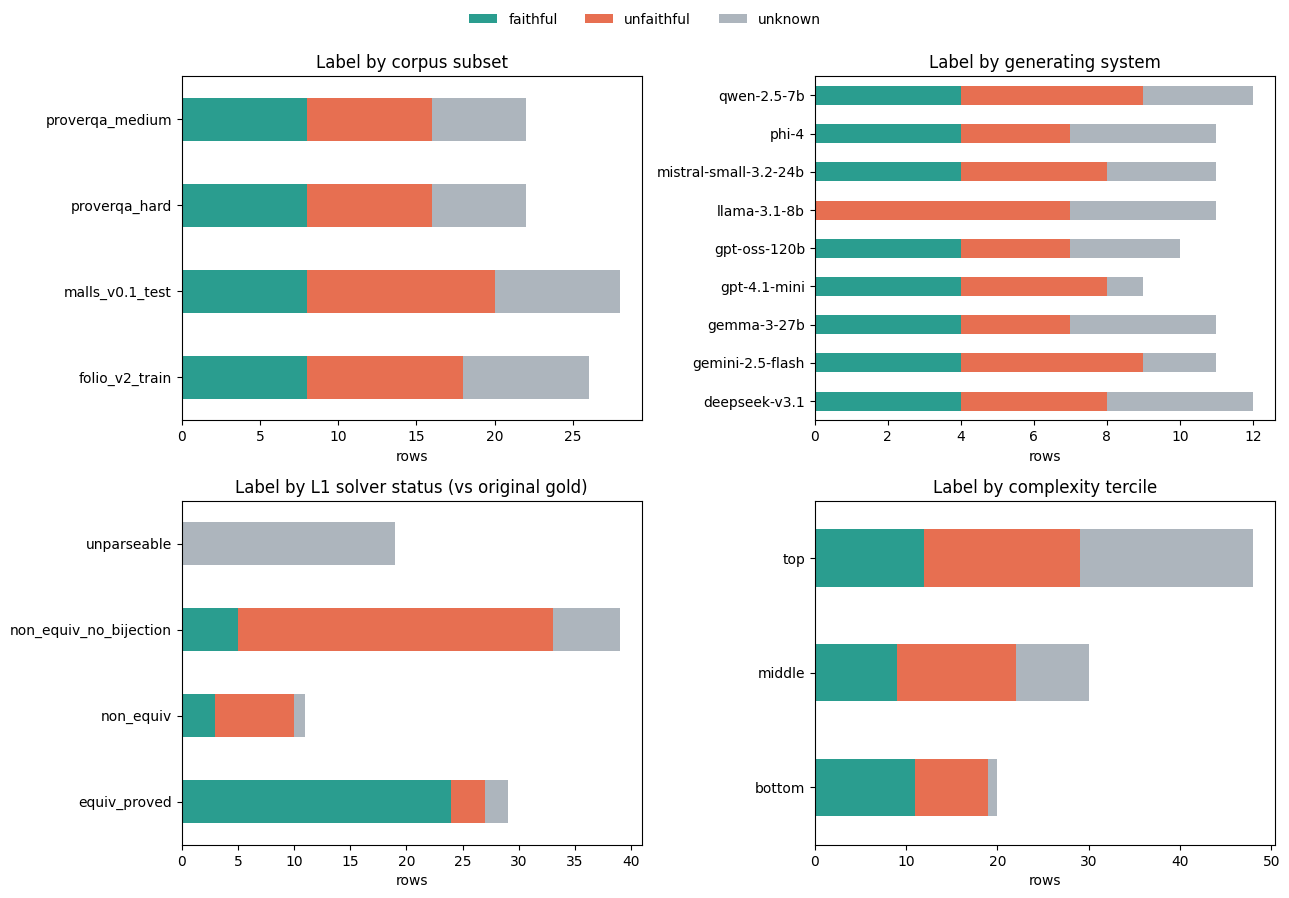

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
colors = {"faithful": "#2a9d8f", "unfaithful": "#e76f51", "unknown": "#adb5bd"}
for ax, col, title in zip(axes.flat, ["corpus", "system", "L1_status", "complexity"],
                          ["Label by corpus subset", "Label by generating system",
                           "Label by L1 solver status (vs original gold)", "Label by complexity tercile"]):
    ct = pd.crosstab(df[col], df["label"]).reindex(columns=[c for c in colors if c in df["label"].unique()])
    ct.plot(kind="barh", stacked=True, ax=ax, color=[colors[c] for c in ct.columns], legend=False)
    ax.set_title(title); ax.set_xlabel("rows"); ax.set_ylabel("")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()